In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('onlinefraud_cleaned.csv')
df.head(10)

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,C1231006815,M1979787155,1,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,C1666544295,M2044282225,1,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,C1305486145,C553264065,0,0.00,181.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,C840083671,C38997010,0,0.00,21363.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,C2048537720,M1230701703,1,0.00,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,C90045638,M573487274,1,0.00,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,C154988899,M408069119,1,0.00,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,C1912850431,M633326333,1,0.00,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,C1265012928,M1176932104,1,1353.36,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,C712410124,C195600860,0,0.00,6886.98,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [4]:
df = pd.get_dummies(df, columns= ['type'], drop_first= True, dtype= int)

In [5]:
df

,hour_of_day,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1,1,0,0,0
6362616,23,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1,0,0,0,1
6362617,23,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1,1,0,0,0
6362618,23,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1,0,0,0,1


In [6]:
X = df.drop(['nameOrig', 'nameDest', 'errorBalanceOrig', 'errorBalanceDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler for val and test
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train_scaled,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 13), (1000000,))

In [7]:
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape

((4453674, 11), (954553, 11), (954393, 11))

In [22]:
def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [ ]:
classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [ ]:
model_comparison_evaluate(classifiers, X_sample, y_sample)

In [8]:
lr_model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

# Logistic Regression
lr_model.fit(x_train_scaled, y_train)

# Random Forest
rf_model.fit(x_train_scaled, y_train)

# XGBoost
xgb_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    verbose= False
)

# Light GBM
lgbm_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    eval_metric='auc',
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
cat_model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )

cat_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
)

CatBoostClassifier(auto_class_weights='Balanced', depth=10, eval_metric='AUC', iterations=200, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

In [12]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

for name, model in models.items():
    pred_proba = model.predict_proba(x_val_scaled)[:, 1]
    auc_score = roc_auc_score(y_val, pred_proba)
    print(f"{name}: {auc_score:.4f}")

Logistic Regression: 0.9908
Random Forest: 0.9988
XGBoost: 0.9999
LightGBM: 0.9999
CatBoost: 0.9999


In [13]:
# Logistic Regression
lr_y_pred = lr_model.predict(x_test_scaled)
lr_y_pred_score = lr_model.predict_proba(x_test_scaled)[:, 1]

print("===========================================================")
print("Logistic Regression:")
print(
    classification_report(
        y_test,
        lr_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)
print("===========================================================")


# Random Forest
rf_y_pred = rf_model.predict(x_test_scaled)
rf_y_pred_score = rf_model.predict_proba(x_test_scaled)[:, 1]

print("Random Forest:")
print(
    classification_report(
        y_test,
        rf_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# XGBoost
xgb_y_pred = xgb_model.predict(x_test_scaled)
xgb_y_pred_score = xgb_model.predict_proba(x_test_scaled)[:,1]

print("XGBoost:")
print(
    classification_report(
        y_test,
        xgb_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# CatBoost
cat_y_pred = cat_model.predict(x_test_scaled)
cat_y_pred_score = cat_model.predict_proba(x_test_scaled)[:,1]

print("Cat Boost:")
print(
    classification_report(
        y_test,
        cat_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# Light GBM
lgbm_y_pred = lgbm_model.predict(x_test_scaled)
lgbm_y_pred_score = lgbm_model.predict_proba(x_test_scaled)[:,1]

print("LightGBM:")
print(
    classification_report(
        y_test,
        lgbm_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

Logistic Regression:
              precision    recall  f1-score   support

   Non-Fraud     0.9999    0.9514    0.9750    953161
       Fraud     0.0244    0.9407    0.0476      1232

    accuracy                         0.9514    954393
   macro avg     0.5122    0.9461    0.5113    954393
weighted avg     0.9987    0.9514    0.9738    954393

Random Forest:
              precision    recall  f1-score   support

   Non-Fraud     0.9997    1.0000    0.9999    953161
       Fraud     0.9771    0.7979    0.8785      1232

    accuracy                         0.9997    954393
   macro avg     0.9884    0.8989    0.9392    954393
weighted avg     0.9997    0.9997    0.9997    954393

XGBoost:
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9998    0.9998    953161
       Fraud     0.8633    0.8766    0.8699      1232

    accuracy                         0.9997    954393
   macro avg     0.9316    0.9382    0.9349    954393
weighted avg     0.9997    0.

#### Find best Thresholds for each model

In [14]:
def find_best_threshold(y_true, y_pred_score):
    thresholds = np.arange(0.01, 1.0, 0.01)

    best_f1 = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (y_pred_score >= t).astype(int)

        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

In [15]:
# Logistic Regression
lr_best_threshold, lr_best_f1 = find_best_threshold(
    y_test,
    lr_y_pred_score
)

print("Logistic Regression")
print("Best Threshold:", lr_best_threshold)
print("Best F1:", lr_best_f1)

# Random Forest
rf_best_threshold, rf_best_f1 = find_best_threshold(
    y_test,
    rf_y_pred_score
)

print("Random Forest")
print("Best Threshold:", rf_best_threshold)
print("Best F1:", rf_best_f1)

# XGBoost
xgb_best_threshold, xgb_best_f1 = find_best_threshold(
    y_test,
    xgb_y_pred_score
)

print("XGBoost")
print("Best Threshold:", xgb_best_threshold)
print("Best F1:", xgb_best_f1)

# Cat Boost
cat_best_threshold, cat_best_f1 = find_best_threshold(
    y_test,
    cat_y_pred_score
)

print("Cat Boost")
print("Best Threshold:", cat_best_threshold)
print("Best F1:", cat_best_f1)

# LightGBM
lgbm_best_threshold, lgbm_best_f1 = find_best_threshold(
    y_test,
    lgbm_y_pred_score
)

print("LightGBM")
print("Best Threshold:", lgbm_best_threshold)
print("Best F1:", lgbm_best_f1)

Logistic Regression
Best Threshold: 0.99
Best F1: 0.44529411764705884
Random Forest
Best Threshold: 0.39
Best F1: 0.8848698720776357
XGBoost
Best Threshold: 0.73
Best F1: 0.8936170212765957
Cat Boost
Best Threshold: 0.99
Best F1: 0.875262494750105
LightGBM
Best Threshold: 0.99
Best F1: 0.8981833544571187


In [16]:
# Logistic Regression
lr_y_pred_score = lr_model.predict_proba(x_test_scaled)[:, 1]
lr_y_pred = (lr_y_pred_score >= lr_best_threshold).astype(int)

print("===========================================================")
print(f"Logistic Regression (Threshold = {lr_best_threshold:.2f})")
print(
    classification_report(
        y_test,
        lr_y_pred,
        digits=4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# Random Forest
rf_y_pred_score = rf_model.predict_proba(x_test_scaled)[:, 1]
rf_y_pred = (rf_y_pred_score >= rf_best_threshold).astype(int)

print(f"Random Forest (Threshold = {rf_best_threshold:.2f})")
print(
    classification_report(
        y_test,
        rf_y_pred,
        digits=4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# XGBoost
xgb_y_pred_score = xgb_model.predict_proba(x_test_scaled)[:, 1]
xgb_y_pred = (xgb_y_pred_score >= xgb_best_threshold).astype(int)

print(f"XGBoost (Threshold = {xgb_best_threshold:.2f})")
print(
    classification_report(
        y_test,
        xgb_y_pred,
        digits=4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

#Cat Boost
cat_y_pred_score = cat_model.predict_proba(x_test_scaled)[:, 1]
cat_y_pred = (cat_y_pred_score >= cat_best_threshold).astype(int)
print(f"Cat Boost (Threshold = {cat_best_threshold:.2f})")
print(
    classification_report(
        y_test,
        cat_y_pred,
        digits=4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# LightGBM
lgbm_y_pred_score = lgbm_model.predict_proba(x_test_scaled)[:, 1]
lgbm_y_pred = (lgbm_y_pred_score >= lgbm_best_threshold).astype(int)

print(f"LightGBM (Threshold = {lgbm_best_threshold:.2f})")
print(
    classification_report(
        y_test,
        lgbm_y_pred,
        digits=4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

Logistic Regression (Threshold = 0.99)
              precision    recall  f1-score   support

   Non-Fraud     0.9995    0.9985    0.9990    953161
       Fraud     0.3492    0.6144    0.4453      1232

    accuracy                         0.9980    954393
   macro avg     0.6743    0.8065    0.7222    954393
weighted avg     0.9987    0.9980    0.9983    954393

Random Forest (Threshold = 0.39)
              precision    recall  f1-score   support

   Non-Fraud     0.9998    1.0000    0.9999    953161
       Fraud     0.9691    0.8141    0.8849      1232

    accuracy                         0.9997    954393
   macro avg     0.9844    0.9070    0.9424    954393
weighted avg     0.9997    0.9997    0.9997    954393

XGBoost (Threshold = 0.73)
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9999    0.9999    953161
       Fraud     0.9392    0.8523    0.8936      1232

    accuracy                         0.9997    954393
   macro avg     0.9695    0.

#### The table of before and after apply thresholds

| Model               | Threshold | Precision (Before) | Recall (Before) | F1 (Before) | Precision (After) | Recall (After) | F1 (After) |      Change |
| ------------------- | --------: | -----------------: | --------------: | ----------: | ----------------: | -------------: | ---------: | ----------: |
| Logistic Regression |      0.99 |             0.0244 |          0.9407 |      0.0476 |            0.3492 |         0.6144 |     0.4453 | **+835.5%** |
| Random Forest       |      0.39 |             0.9771 |          0.7979 |      0.8785 |            0.9691 |         0.8141 |     0.8849 |  **+0.73%** |
| XGBoost             |      0.73 |             0.8633 |          0.8766 |      0.8699 |            0.9392 |         0.8523 |     0.8936 |  **+2.72%** |
| CatBoost            |      0.99 |             0.3188 |          0.9943 |      0.4829 |            0.9069 |         0.8458 |     0.8753 | **+81.26%** |
| LightGBM            |      0.99 |             0.3821 |          0.9927 |      0.5518 |            0.9366 |         0.8628 |     0.8982 | **+62.78%** |


#### Logistic Regression

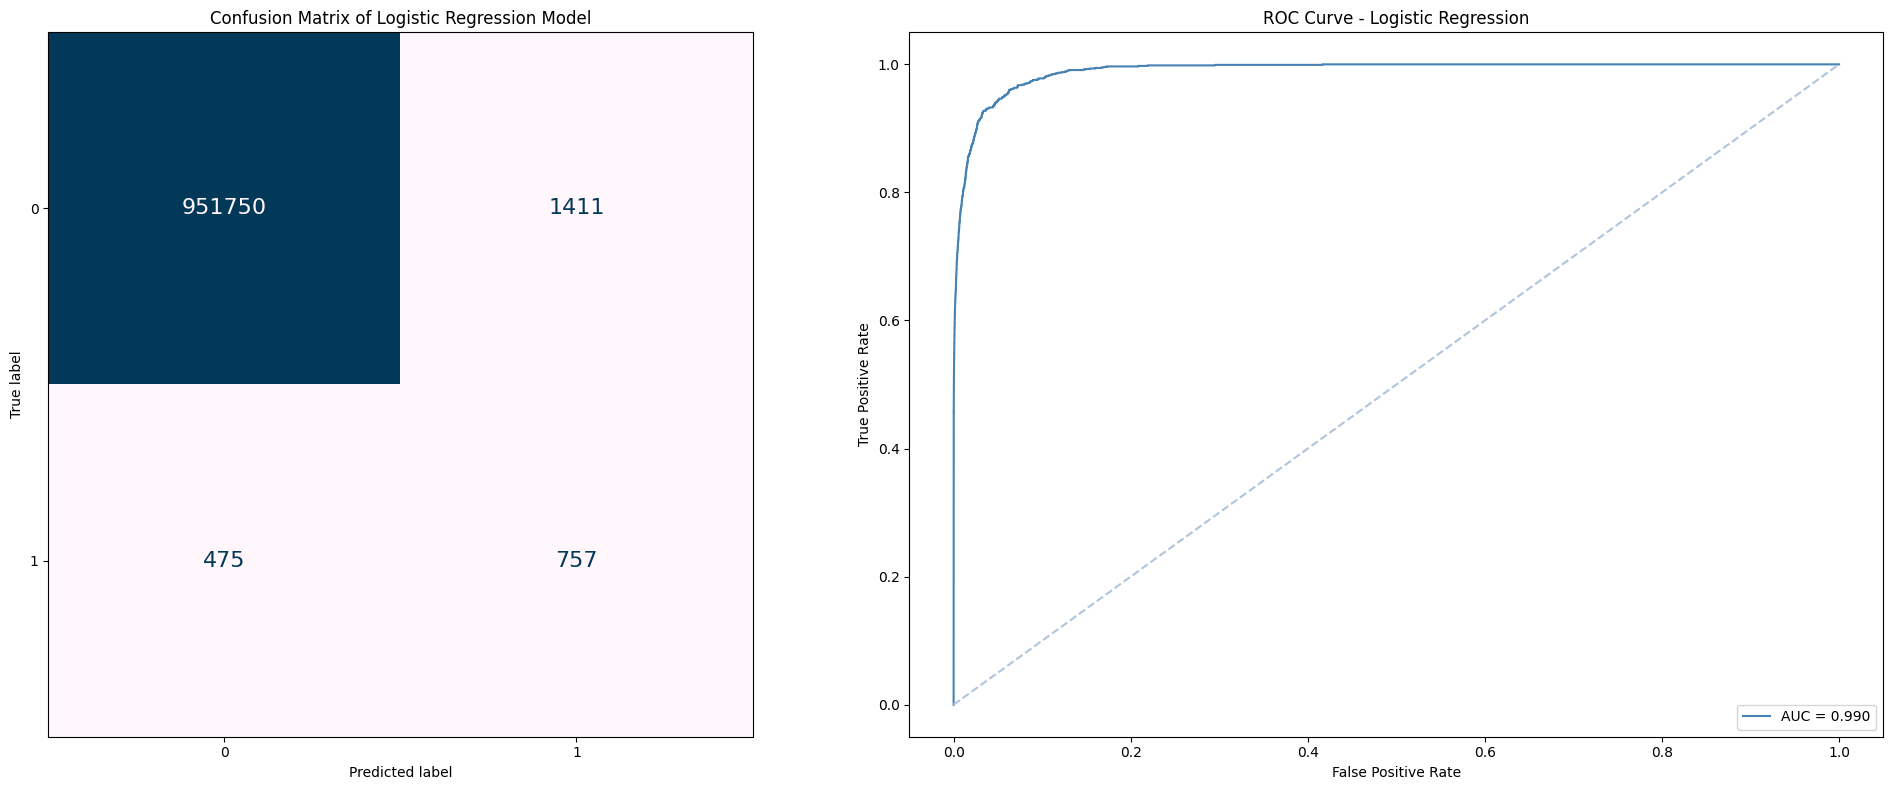

In [17]:
from sklearn.metrics import auc
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Logistic Regression Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lr_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Logistic Regression')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Random Forest

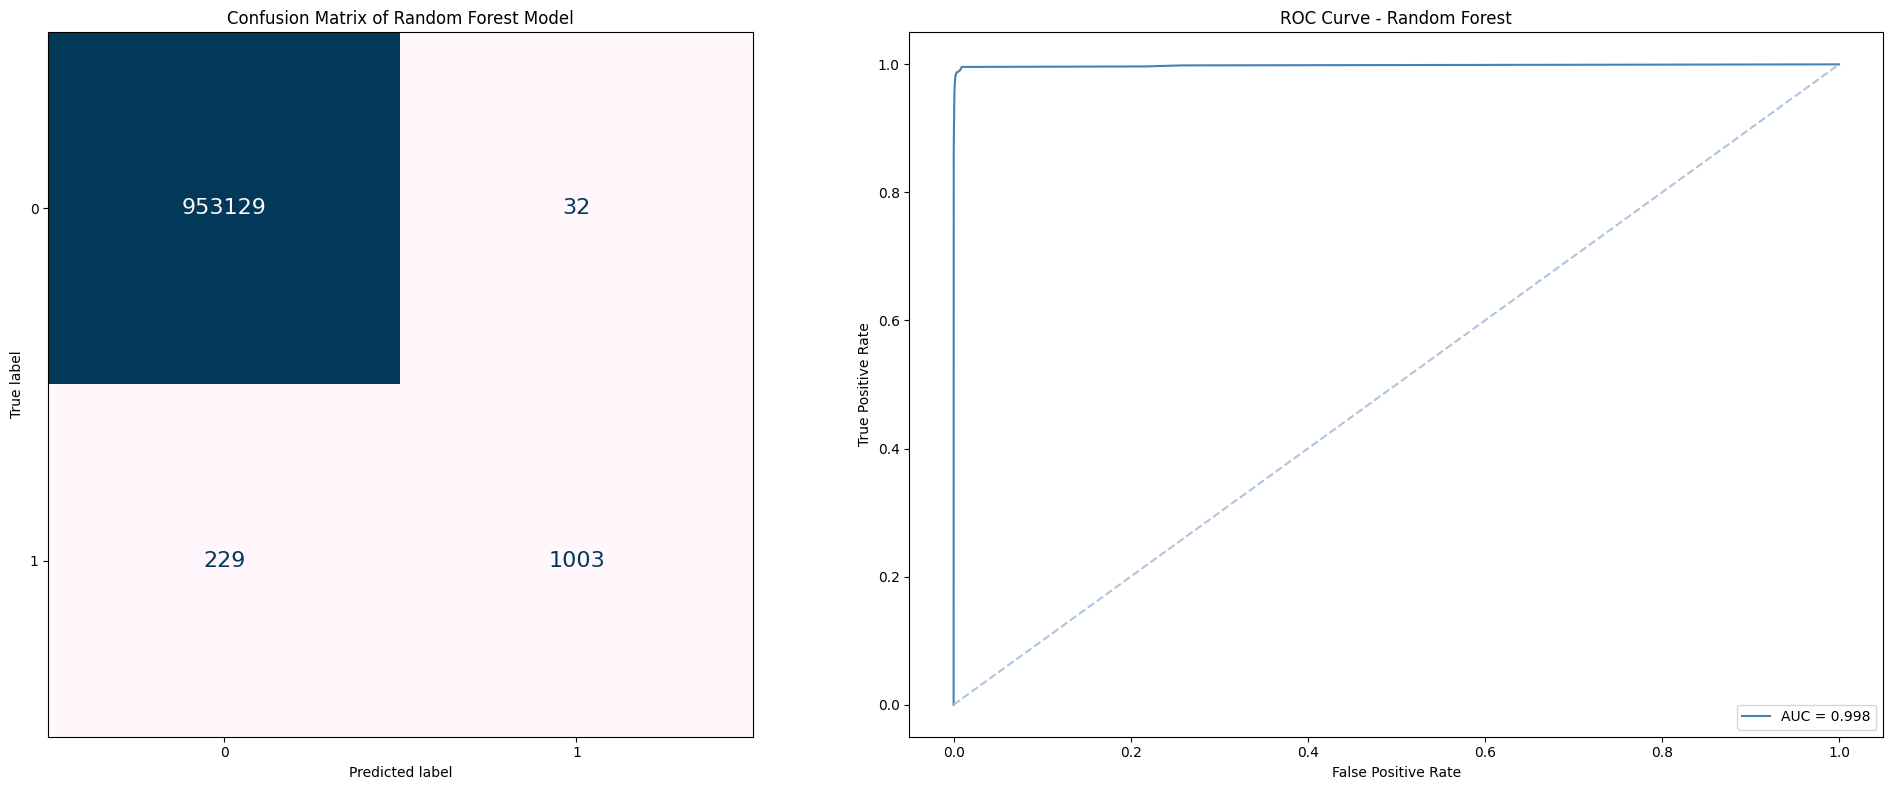

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Random Forest Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Random Forest')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### XGBoost

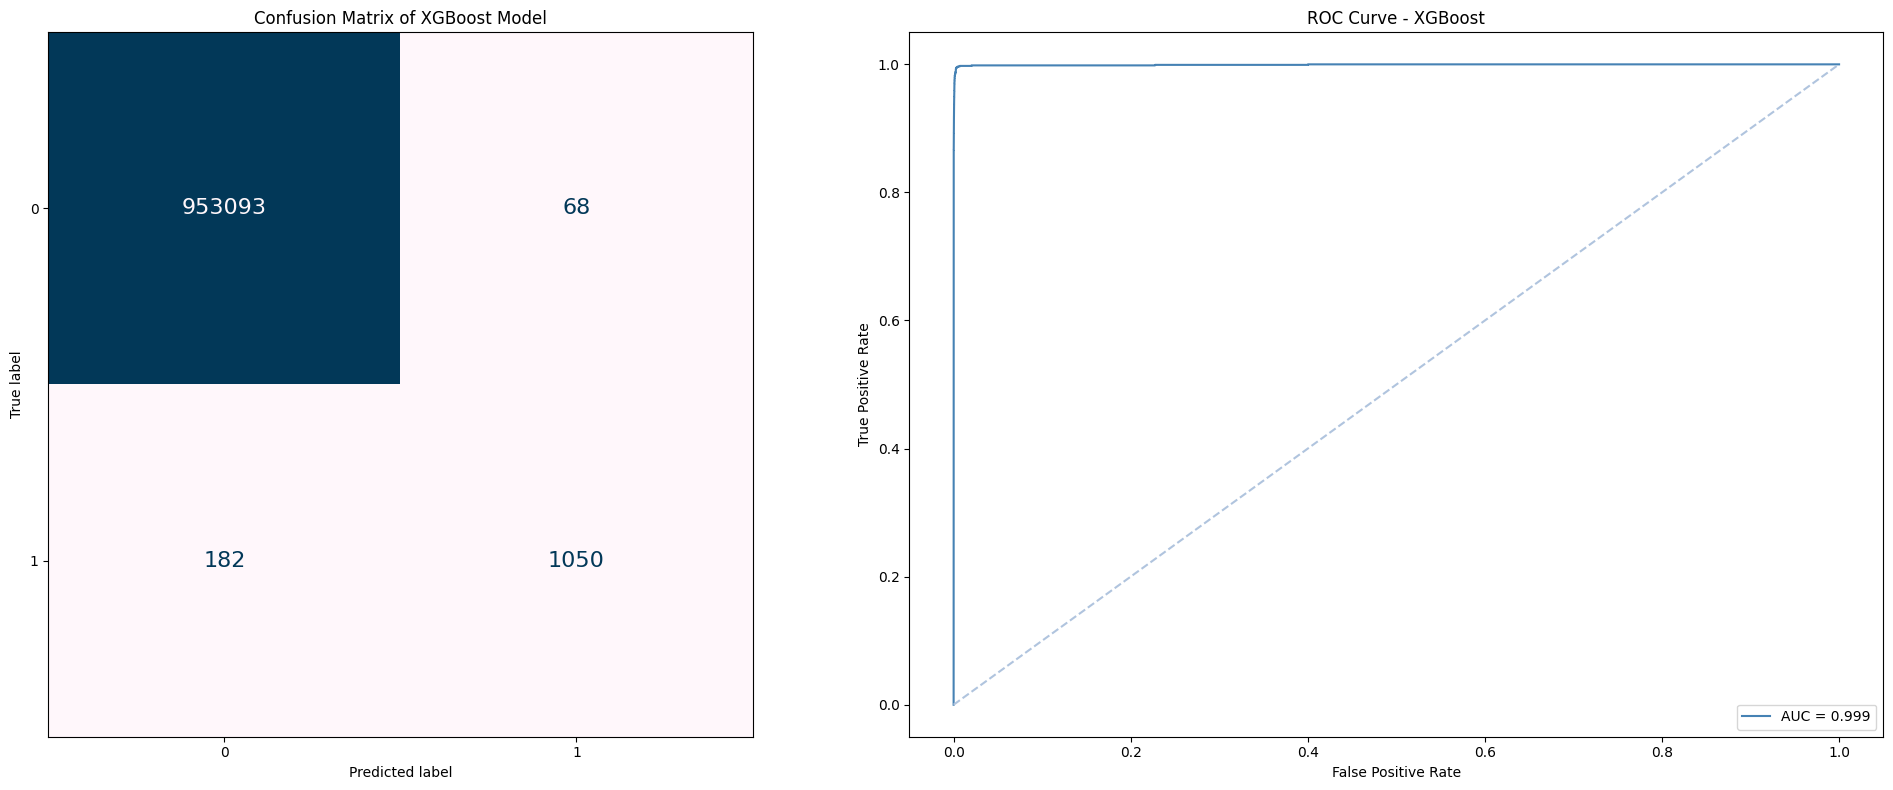

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of XGBoost Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, xgb_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - XGBoost')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Cat Boost

Text(0.5, 0, 'False Positive Rate')

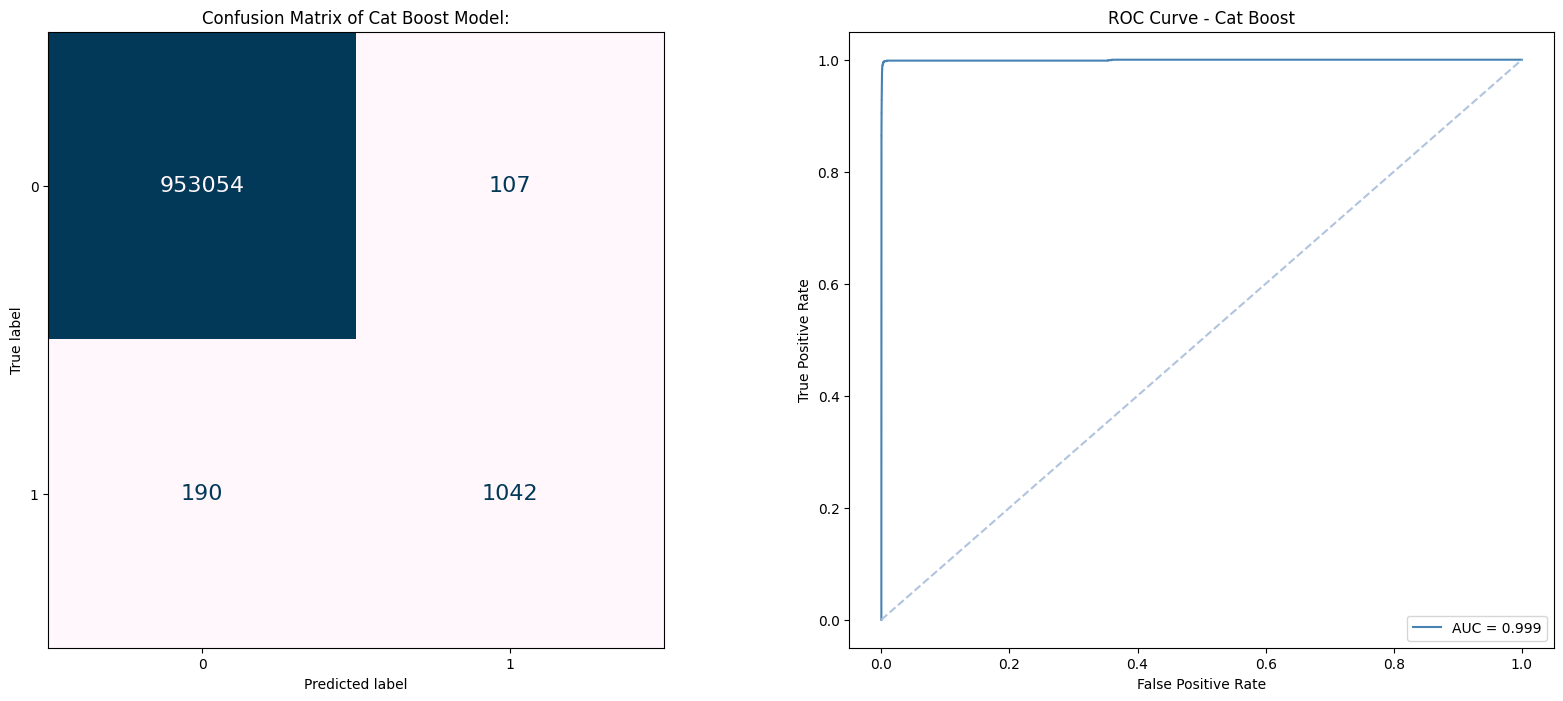

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Cat Boost Model:')
ConfusionMatrixDisplay.from_predictions(y_test, cat_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, cat_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Cat Boost')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

#### Light GBM

Text(0.5, 0, 'False Positive Rate')

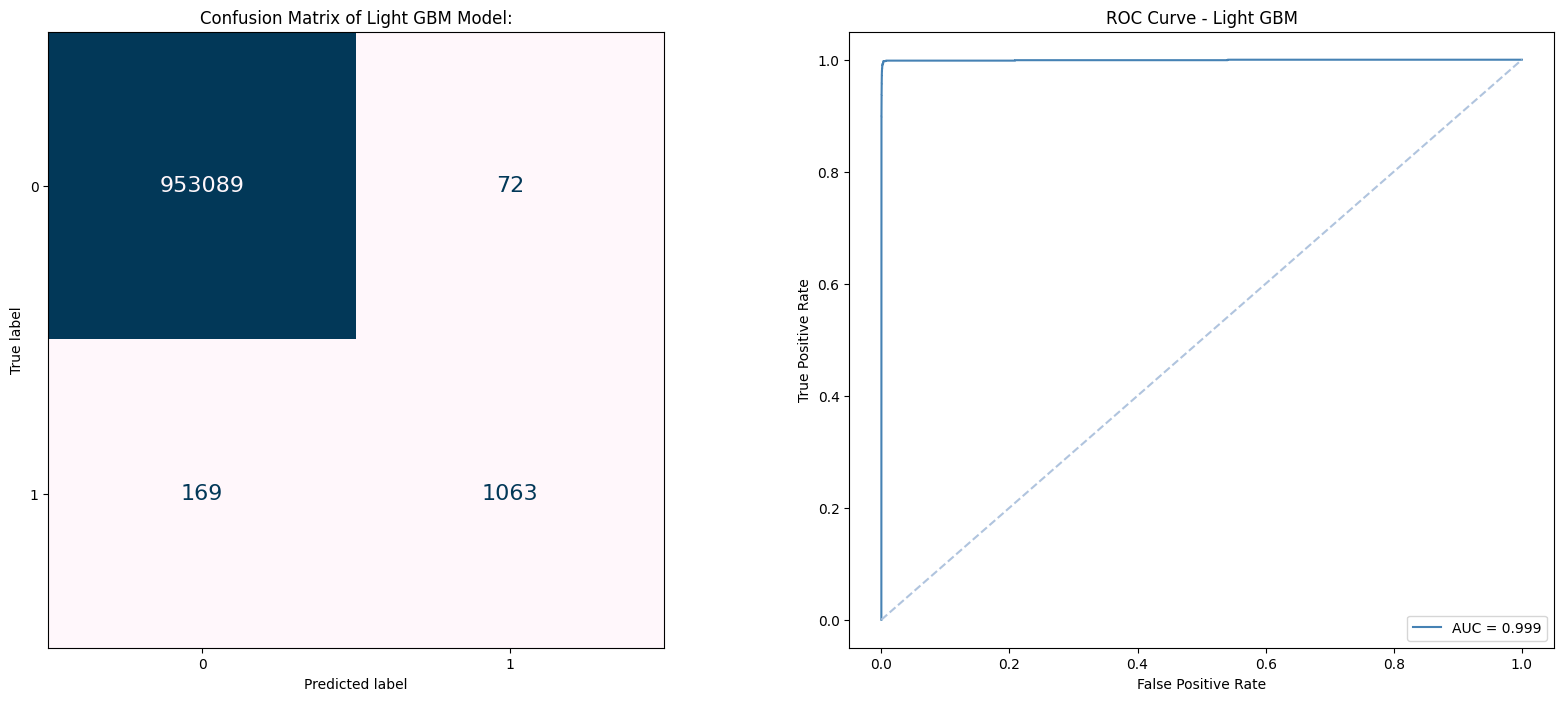

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Light GBM Model:')
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, lgbm_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Light GBM')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

- Note: Logistic Regression doesn't have feature importance

In [23]:
# Random Forest
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
2      oldbalanceOrg    0.302734
3     newbalanceOrig    0.167797
1             amount    0.153614
10     type_TRANSFER    0.070928
4     oldbalanceDest    0.060031
5     newbalanceDest    0.055567
6   is_Merchant_Dest    0.051137
0        hour_of_day    0.048370
7      type_CASH_OUT    0.046722
9       type_PAYMENT    0.042735
8         type_DEBIT    0.000365


In [24]:
# XGBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
3     newbalanceOrig    0.343547
6   is_Merchant_Dest    0.196373
9       type_PAYMENT    0.141995
7      type_CASH_OUT    0.094241
10     type_TRANSFER    0.084900
2      oldbalanceOrg    0.047454
1             amount    0.028370
5     newbalanceDest    0.022985
0        hour_of_day    0.016826
8         type_DEBIT    0.013292
4     oldbalanceDest    0.010017


In [25]:
# Light GBM
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
1             amount        1805
2      oldbalanceOrg        1533
5     newbalanceDest         801
4     oldbalanceDest         651
0        hour_of_day         606
3     newbalanceOrig         189
7      type_CASH_OUT         138
10     type_TRANSFER         134
6   is_Merchant_Dest         102
8         type_DEBIT          27
9       type_PAYMENT          14
